In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
import joblib
from src.Utils import shifted_mape, plot_performance_analysis, mse_column_score

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
random_model = RandomForestRegressor(n_jobs=1, random_state=42)
random_grid = {
    'n_estimators': randint(30, 251),
    'max_depth': randint(10, 51),
    'min_samples_split': randint(2, 21),
    'max_features': uniform(0.1, 0.9)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring,
                                   refit='mse_global', n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....0021282E53C10>, 'max_features': <scipy.stats....0021282E585D0>, 'min_samples_split': <scipy.stats....0021282E52150>, 'n_estimators': <scipy.stats....00212FE92C3D0>}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [6]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(x_test)
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.0367535049742406


,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,-0.039813,-0.042550,-0.001506
1,-0.037342,-0.039903,-0.001481
2,-0.044882,-0.047961,-0.001776
3,-0.040715,-0.043507,-0.001616
4,-0.049483,-0.052899,-0.001663
5,-0.038618,-0.041270,-0.001501
6,-0.037704,-0.040290,-0.001488
7,-0.040845,-0.043646,-0.001626
8,-0.045786,-0.048941,-0.001609
9,-0.043150,-0.046110,-0.001714


In [7]:
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')

In [8]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003172,0.003178,0.003181,0.003181,0.003181,0.003182,0.003180,0.003180,0.003180,0.003180,0.003180,0.004286,0.004286,0.497638,0.028974
MAPE,0.001607,0.001611,0.001613,0.001613,0.001613,0.001614,0.001612,0.001613,0.001613,0.001613,0.001613,0.002166,0.002166,0.056219,0.027445
R2,0.916131,0.917289,0.917901,0.917962,0.917992,0.918043,0.918039,0.918012,0.918042,0.918086,0.918097,0.796634,0.796651,0.947752,0.544555


In [9]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003172,0.003178,0.003181,0.003181,0.003181,0.003182,0.003180,0.003180,0.003180,0.003180,0.003180,0.004286,0.004286,0.497638,2.897384e-02
MAPE,0.003259,0.003268,0.003272,0.003272,0.003273,0.003275,0.003270,0.003271,0.003272,0.003272,0.003272,0.004379,0.004378,0.065490,5.633787e+13
R2,0.916131,0.917289,0.917901,0.917962,0.917992,0.918043,0.918039,0.918012,0.918042,0.918086,0.918097,0.796634,0.796651,0.947752,5.445553e-01


In [10]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.003350,0.497638,0.028974
MAPE,0.001697,0.056219,0.027445
R2,0.899145,0.947752,0.544555


In [11]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.003350,0.497638,2.897384e-02
MAPE,0.003441,0.065490,5.633787e+13
R2,0.899145,0.947752,5.445553e-01


**Validación Cruzada para Contrastación de Resultados**

In [12]:
random_search.best_params_

{'max_depth': 38,
 'max_features': np.float64(0.8219772826786357),
 'min_samples_split': 2,
 'n_estimators': 118}

In [13]:
evaluate_model_shifted = RandomForestRegressor(max_depth=38, max_features=0.82, min_samples_split=2, n_estimators=118, n_jobs=1, random_state=42)
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.03789732674591409
MAE: 0.04013801816412112
MAPE: 0.007386387797225497
R2: 0.8723182531812876


In [14]:
evaluate_model = RandomForestRegressor(max_depth=38, max_features=0.82, min_samples_split=2, n_estimators=118, n_jobs=1, random_state=42)
evaluate_scoring = { # EVALUACIÓN SIN DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.03789732674591409
MAE: 0.04013801816412112
MAPE: 3869547302425.0225
R2: 0.8723182531812876


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [15]:
joblib.dump(best_random_model, '../models/MO_RandomForest.pkl')

['../models/MO_RandomForest.pkl']

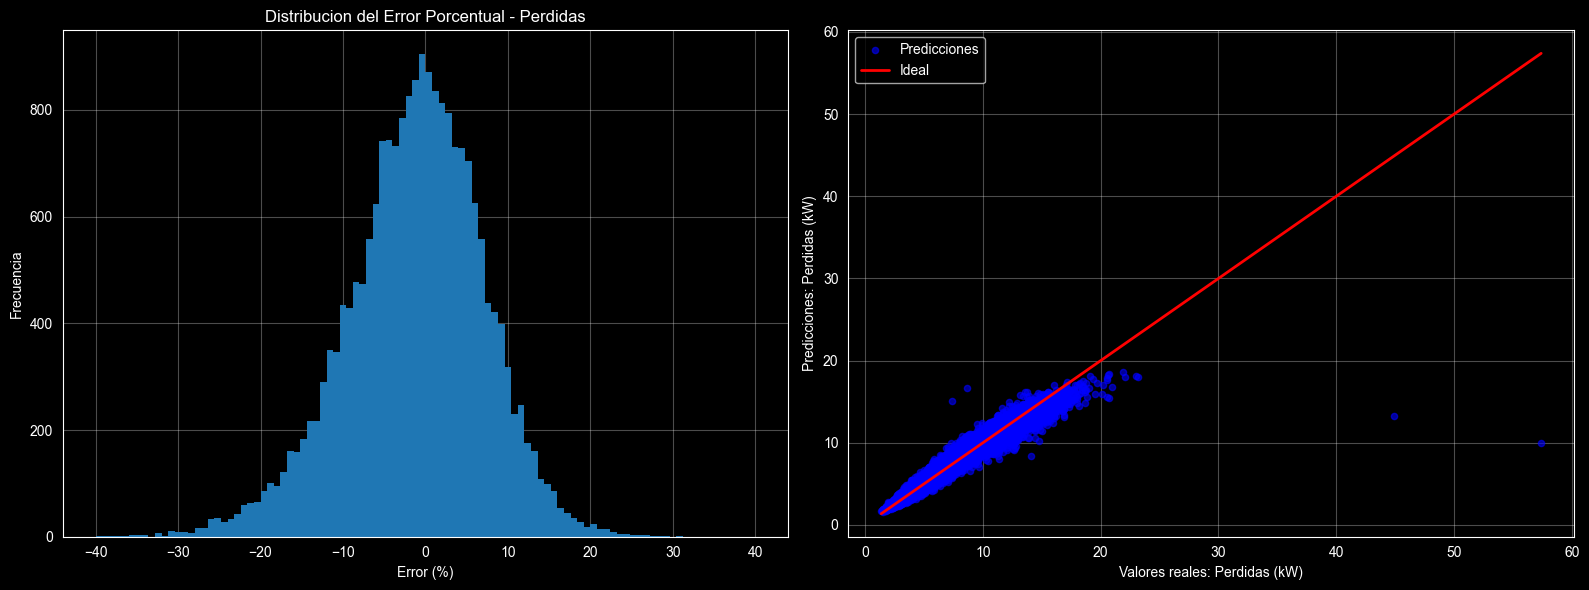

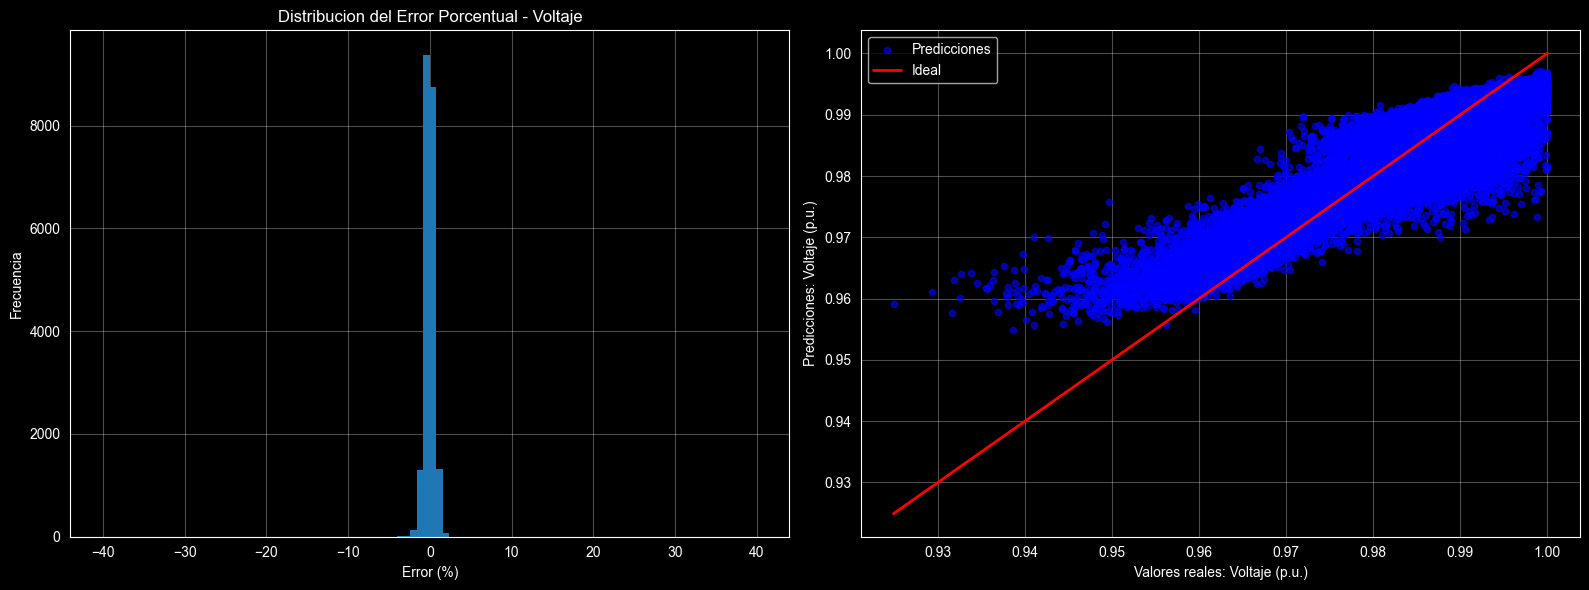

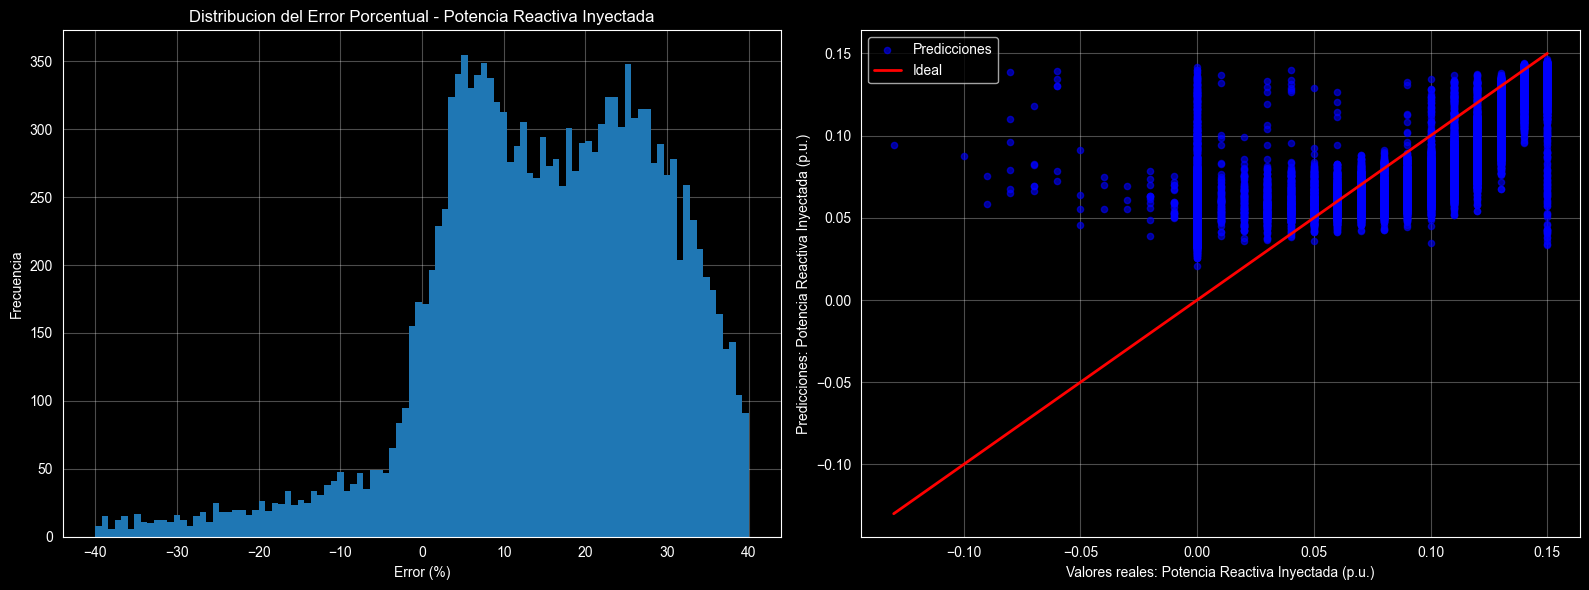

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/RandomForest/MO_RandomForest_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    random_predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/RandomForest/MO_RandomForest_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/RandomForest/MO_RandomForest_QGen.png'
)